# Import Libraries

In [25]:
# Import NumPy for numerical operations and array handling.
import numpy as np
# Import pandas for loading, cleaning, and manipulating tabular data.
import pandas as pd
# Import Matplotlib's pyplot interface for static plots.
import matplotlib.pyplot as plt
# Import Plotly Express for interactive visualizations.
import plotly.express as px
# Import Seaborn for statistical plots such as heatmaps, histograms, box plots, and scatter plots.
import seaborn as sns
# Import Python's warnings module so warnings can be controlled if needed.
import warnings

# **About [Dataset](https://www.kaggle.com/datasets/jjayfabor/lettuce-growth-days/data)**

This comprehensive dataset provides valuable insights into the growth patterns of various plants under different environmental conditions. Collected over time, it offers a detailed view of how factors such as temperature, humidity, pH level, and Total Dissolved Solids (TDS) affect the growth stages and development of these plants.

---
*   Plant_ID: Identifier for each plant.
*   Date: The date of the observation.
*   Temperature (°C): The temperature in degrees Celsius.
*   Humidity (%): The humidity level in percentage.
*   TDS Value (ppm): The Total Dissolved Solids value in parts per million.
*   pH Level: The pH level of the environment.
*   Growth Days: The number of days since the plant started growing until fully grown.





# Exploratory Data Analysis

### Read Dataset

In [26]:
# Read the lettuce CSV dataset into a pandas DataFrame named lettuce_df.
lettuce_df = pd.read_csv('lettuce_dataset.csv', encoding='latin1')

### Display data records

In [27]:
# Display the first five rows to verify that the dataset loaded correctly.
lettuce_df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,1,8/3/2023,33.4,53,582,6.4,1
1,1,8/4/2023,33.5,53,451,6.1,2
2,1,8/5/2023,33.4,59,678,6.4,3
3,1,8/6/2023,33.4,68,420,6.4,4
4,1,8/7/2023,33.4,74,637,6.5,5


#### Analysis:

The data are recorded longitudinally by plant and day of growth. `Growth Days` is behaving as the elapsed growth-day target, while the environmental variables change from observation to observation. 

The first five observations are for `Plant_ID = 1`, dated 2023-08-03 through 2023-08-07. Temperature is around 33.4–33.5°C, humidity rises from 53% to 74%, TDS varies from 420 to 678 ppm, pH is 6.1–6.5, and Growth Days increases from 1 to 5.

This confirms that the dataset is suitable for investigating whether environmental conditions are associated with the time required for lettuce growth.

### Display data shape

In [28]:
# Return the number of rows and columns in the dataset as (rows, columns).
lettuce_df.shape

(3169, 7)

#### Analysis

The dataset contains 3,169 time-series entries and 7 variables: Plant_ID, Date, Temperature, Humidity, TDS Value, pH Level, and Growth Days. These variables capture plant identification, time-related information, environmental conditions, water quality, and plant growth duration.

## Identify data types

In [29]:
# Display column names, non-null counts, and detected data types.
lettuce_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 173.4+ KB


### Count the missing values

In [30]:
# Count missing values in every column to identify incomplete data.
lettuce_df.isna().sum()

Plant_ID            0
Date                0
Temperature (°C)    0
Humidity (%)        0
TDS Value (ppm)     0
pH Level            0
Growth Days         0
dtype: int64

#### Analysis

There are no incomplete columns at this stage, and the numerical variables have usable numeric data types. 

There are 4 integer columns (`Plant_ID`, `Humidity`, `TDS Value`, `Growth Days`), 2 floating-point columns (`Temperature`, `pH Level`), and `Date` is initially stored as an object/string.

The only preprocessing issue identified here is the date type, which needs conversion before time-based analysis.

## Count duplicated values

In [31]:
# Count duplicated rows to check whether the dataset contains exact duplicate records.
lettuce_df.duplicated().sum()

np.int64(0)

#### Analysis

There are no exact duplicate rows in the dataset. Therefore, the analysis does not need a duplicate-removal step, and each recorded row represents a distinct combination of the stored variables.

### Check 'Max Growth Days'

In [32]:
# Group by Plant_ID and get the maximum growth days
max_growth_days = lettuce_df.groupby('Plant_ID')['Growth Days'].max()

# Count how many times each maximum growth day appears
count_max_growth_days = max_growth_days.value_counts().reset_index()
count_max_growth_days.columns = ['Max Growth Days', 'Count']

# Display the result
print(count_max_growth_days)

   Max Growth Days  Count
0               45     59
1               47      5
2               46      5
3               48      1


#### Analysis of the actual output

Approximately 84% of plants (59/70) reach their maximum recorded growth at 45 days. Only 11 plants exceed 45 days. This concentration means that the model is predicting a target with substantial clustering around typical growth durations rather than a uniformly distributed range.

## Display summary tables

In [33]:
lettuce_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Plant_ID,3169.0,35.44,20.24,1.0,18.0,35.0,53.0,70.0
Temperature (°C),3169.0,28.14,4.67,18.0,23.6,30.2,31.5,33.5
Humidity (%),3169.0,64.87,8.99,50.0,57.0,65.0,73.0,80.0
TDS Value (ppm),3169.0,598.05,115.71,400.0,498.0,593.0,699.0,800.0
pH Level,3169.0,6.40,0.23,6.0,6.2,6.4,6.6,6.8
Growth Days,3169.0,23.14,13.08,1.0,12.0,23.0,34.0,48.0


### Analysis

Growth Days spans almost the entire 1–48 day range. Temperature is more unevenly distributed than the other environmental variables because its mean is noticeably below its median, which is consistent with the two-cluster appearance in the histogram. Humidity, TDS, and pH have means close to their medians, indicating relatively balanced central distributions. The target has substantial variability (SD ≈ 13.08 days), so there is meaningful variation for a regression model to explain.

### Convert 'Date' column to datetime

In [34]:
# Convert the Date column from text/object values into pandas datetime values.
lettuce_df['Date'] = pd.to_datetime(lettuce_df['Date'])
lettuce_df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,1,2023-08-03,33.4,53,582,6.4,1
1,1,2023-08-04,33.5,53,451,6.1,2
2,1,2023-08-05,33.4,59,678,6.4,3
3,1,2023-08-06,33.4,68,420,6.4,4
4,1,2023-08-07,33.4,74,637,6.5,5


Visualize correlation matrix

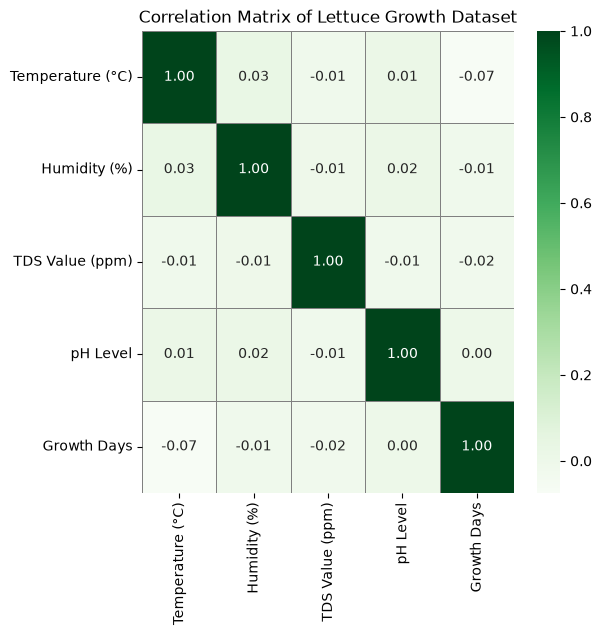

In [35]:
# Visualize the correlation matrix

plt.figure(figsize=(6, 6))
sns.heatmap(
    lettuce_df.drop(columns=["Date", "Plant_ID"]).corr(), 
    annot=True, 
    cmap ='Greens', 
    linewidth=.6, linecolor = 'grey',
    fmt=".2f"
            )
plt.title('Correlation Matrix of Lettuce Growth Dataset')
plt.show()

#### Analysis:

The correlation values between the input variables and Growth Days are all close to 0, ranging from -0.07 to 0.00. This means that there is very little linear relationship between the environmental variables and Growth Days. Temperature has the strongest relationship at -0.07, but it is still very weak. Therefore, no single variable appears to strongly explain Growth Days based on linear correlation alone.

# Data Visualization

## Visualize the distributions of data

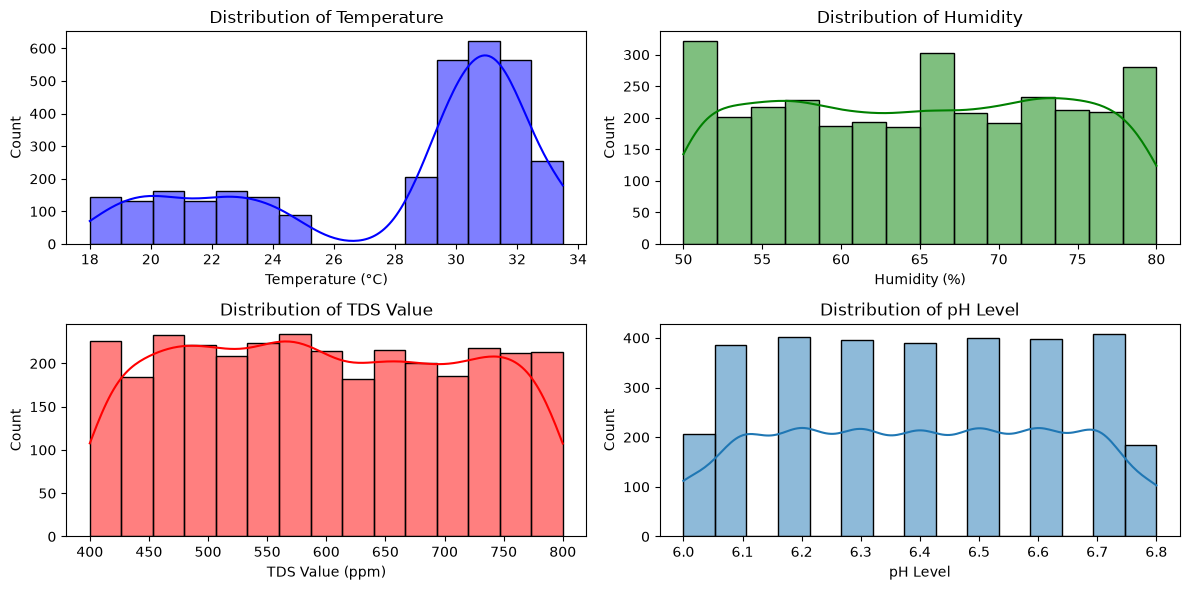

In [36]:
# Plotting Histograms for Distributions
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
sns.histplot(lettuce_df['Temperature (°C)'], kde=True, color='blue')
plt.title('Distribution of Temperature')

plt.subplot(2, 2, 2)
sns.histplot(lettuce_df['Humidity (%)'], kde=True, color='green')
plt.title('Distribution of Humidity')

plt.subplot(2, 2, 3)
sns.histplot(lettuce_df['TDS Value (ppm)'], kde=True, color='red')
plt.title('Distribution of TDS Value')

plt.subplot(2, 2, 4)
sns.histplot(lettuce_df['pH Level'], kde=True)
plt.title('Distribution of pH Level')

plt.tight_layout()
plt.show()

#### Analysis:

Temperature is concentrated in two visible regions, with many observations around 29–33.5°C and a smaller lower-temperature group around 18–25°C. Humidity levels appear uniformly distributed between 50% and 80%, without significant peaks, while CO₂ concentrations are relatively evenly spread across 400 ppm to 800 ppm. Similarly, pH values are nearly evenly distributed between 6.0 and 6.8, suggesting a neutral to slightly acidic range.

Temperature has the most visibly non-uniform distribution and appears clustered rather than approximately symmetric. Humidity and TDS cover their observed ranges relatively broadly, while pH takes a narrow set of discrete values. Because the environmental variables occupy limited but distinct ranges, the model is learning within the observed experimental conditions rather than across a very wide environmental domain.

## Visualize the outliers

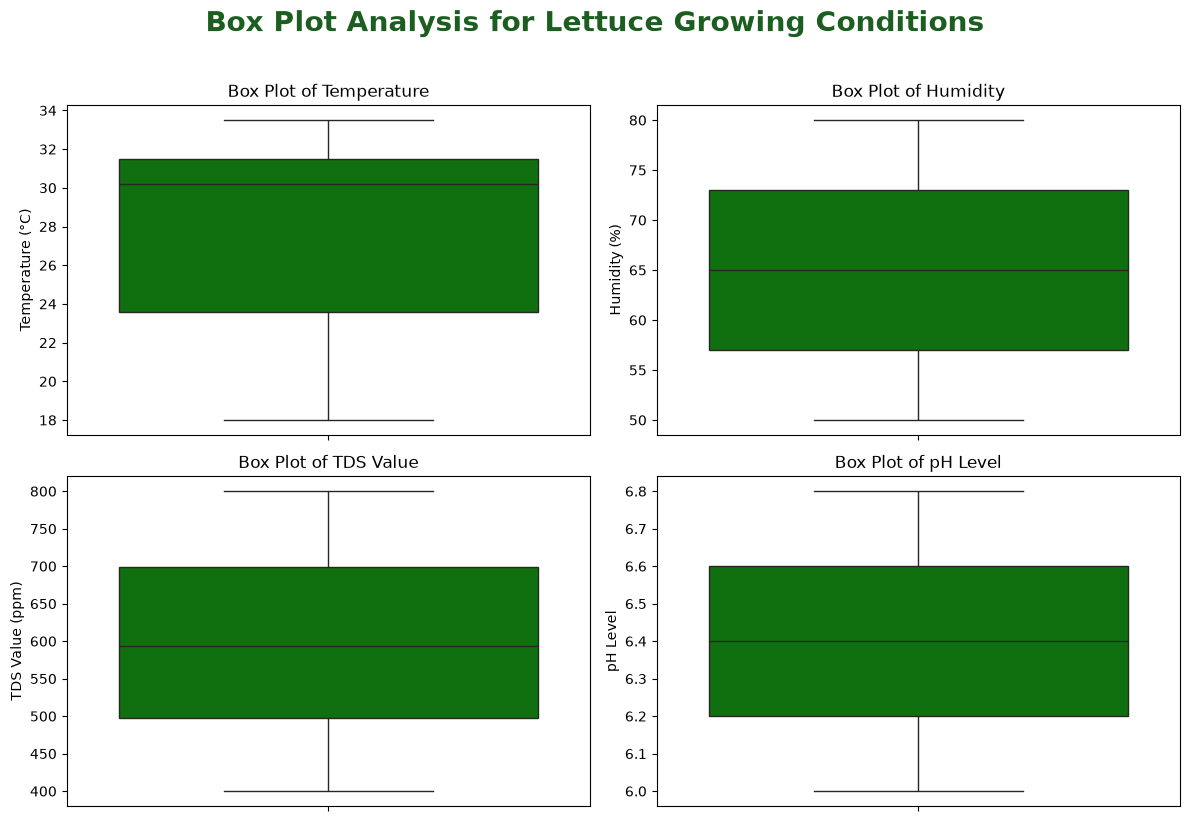

In [44]:
# Create Box plots to identify outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=lettuce_df['Temperature (°C)'], color='green')
plt.title('Box Plot of Temperature')

plt.subplot(2, 2, 2)
sns.boxplot(y=lettuce_df['Humidity (%)'], color='green')
plt.title('Box Plot of Humidity')

plt.subplot(2, 2, 3)
sns.boxplot(y=lettuce_df['TDS Value (ppm)'], color='green')
plt.title('Box Plot of TDS Value')

plt.subplot(2, 2, 4)
sns.boxplot(y=lettuce_df['pH Level'], color='green')
plt.title('Box Plot of pH Level')

fig.suptitle(
    'Box Plot Analysis for Lettuce Growing Conditions',
    fontsize=20,
    fontweight='bold',
    color='#1B5E20',
    y=1.02
)


plt.tight_layout()
plt.show()

#### Analysis:

The boxplots show Temperature from 18 to 33.5°C, Humidity from 50% to 80%, TDS from 400 to 800 ppm, and pH from 6.0 to 6.8.

These box plots demonstrate that values for all parameters are largely within expected ranges with no visible outliers. 

### Bivariate Analysis

In [46]:
# Create Scatter plots for relationships using plotly.express
fig = px.scatter(lettuce_df, x='Temperature (°C)',
                 y='Growth Days', title='Temperature vs. Growth Days',
                 color='Temperature (°C)',
                 color_continuous_scale='solar',
                 width=500, height=500)
fig.show()

#### Analysis
The Temperature vs. Growth Days scatterplot shows observations spread across the temperature range without a strong visible upward or downward pattern. The correlation matrix also gives Temperature vs. Growth Days a correlation of about -0.07.

Temperature alone has little linear association with Growth Days in these observations. A model may still use temperature in combination with other variables, but the scatterplot does not support a strong one-variable linear relationship.

In [47]:
fig = px.scatter(lettuce_df, x='Humidity (%)',
                 y='Growth Days', title='Humidity vs. Growth Days',
                 color='Humidity (%)',
                 color_continuous_scale='viridis',
                 width=500, height=500)
fig.show()

#### Analysis

The Humidity vs. Growth Days scatterplot shows Growth Days distributed broadly across the 50–80% humidity range, without a clear monotonic trend. The correlation is approximately -0.01.

Humidity has essentially no linear relationship with Growth Days in this dataset when considered alone. Its predictive contribution, if any, is therefore more likely to come through interactions or nonlinear combinations with other variables rather than a simple linear effect.

In [51]:
fig = px.scatter(lettuce_df, x='TDS Value (ppm)',
                 y='Growth Days', title='TDS Value vs. Growth Days',
                 color='TDS Value (ppm)',
                 color_continuous_scale='matter',
                 width=500, height=500)
fig.show()

#### Analysis

The TDS vs. Growth Days scatterplot shows Growth Days spread throughout the observed TDS range of roughly 400–800 ppm, with no strong visible trend. The correlation is approximately -0.02.

TDS has almost no linear association with Growth Days by itself. This agrees with the correlation matrix and indicates that TDS alone does not explain much of the variation in the target.

In [49]:
fig = px.scatter(lettuce_df, x='pH Level',
                 y='Growth Days', title='pH Level vs. Growth Days',
                 color='pH Level',
                 color_continuous_scale='mint',
                 width=500, height=500)
fig.show()

### Analysis
The pH vs. Growth Days scatterplot covers the narrow pH range of 6.0–6.8 and does not show a clear increasing or decreasing pattern. The correlation with Growth Days is approximately 0.00.

pH has essentially zero linear correlation with Growth Days in the recorded data. Its narrow range also limits how much variation in growth duration can be attributed to pH within this particular dataset.

# Data Pre-processing

## Three (3) Alternative Designs

In [52]:
lettuce_df.columns

Index(['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)',
       'TDS Value (ppm)', 'pH Level', 'Growth Days'],
      dtype='object')

In [53]:
# Select relevant features and target variable
X = lettuce_df.drop(['Plant_ID', 'Date', 'Growth Days'], axis=1)
y = lettuce_df['Growth Days']

### Random Forest

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### XGBoost

In [55]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### (1)


In [56]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test_scaled)

In [57]:
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("\n")

evaluate_model("XGBoost", y_test, xgb_pred)

--- XGBoost Performance ---
MAE: 4.91
MSE: 61.39
RMSE: 7.84
R^2 Score: 0.64




##### Analysis

The model's predictions are off by about 4.91 days on average according to MAE, while the RMSE of 7.84 days indicates some larger errors. An R² of 0.64 means the model explains about 64% of the variance in the held-out Growth Days values.

#### (2)


In [58]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

xgb_model = XGBRegressor(
    booster="gbtree",
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=3,
    random_state=42,
    eval_metric=["rmse", "mae"],  # Add multiple metrics
    early_stopping_rounds=50,  # Stops if no improvement
    )

xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=eval_set,
    verbose=False
)
# Make predictions
xgb_pred = xgb_model.predict(X_test_scaled)

In [59]:
evaluate_model("XGBoost", y_test, xgb_pred)

--- XGBoost Performance ---
MAE: 4.99
MSE: 59.28
RMSE: 7.70
R^2 Score: 0.66




##### Analysis

Compared with the first XGBoost setup, MSE decreases from 61.39 to 59.28, RMSE decreases from 7.84 to 7.70, and R² increases from 0.64 to 0.66. MAE increases slightly from 4.91 to 4.99. Overall, the second model gives slightly better squared-error performance and explains more variance, although its typical absolute error is marginally worse.

#### (3)

In [60]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [100, 500, 1000],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 1],
}

# Initialize model
xgb_model = XGBRegressor(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  # Use appropriate scoring metric
    cv=3,  # 3-fold cross-validation
    verbose=True,  # Show progress
    n_jobs=-1  # Use all available cores
)

grid_search.fit(X_train_scaled, y_train, verbose=True)  # Show progress


# Get best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)

Fitting 3 folds for each of 2187 candidates, totalling 6561 fits
Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 1.0}
Best Score (MSE): 65.55243682861328


In [61]:
# Get the best XGBoost model found by GridSearchCV.
best_xgb_model = grid_search.best_estimator_

# Use the best model to predict the unseen test data.
y_pred = best_xgb_model.predict(X_test_scaled)

# Calculate Mean Absolute Error.
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error.
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error.
rmse = np.sqrt(mse)

# Calculate R² score.
r2 = r2_score(y_test, y_pred)

# Display the final test-set performance.
print("Final Test Performance")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Final Test Performance
MAE:  5.1561
MSE:  60.8398
RMSE: 7.8000
R²:   0.6479


##### Analysis

Hyperparameter tuning produces a model with solid generalization performance, but it does **not** improve on the earlier early-stopping XGBoost result on this same test split: the earlier model has MAE 4.99, RMSE 7.70, and R² 0.66 versus 5.16, 7.80, and 0.65 after GridSearch. Therefore, the tuned model should not be claimed as the best-performing XGBoost configuration solely because it was selected by GridSearchCV.

### Support Vector Regression

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)

In [ ]:
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("\n")

evaluate_model("SVR", y_test, svr_pred)

--- SVR Performance ---
MAE: 10.81
MSE: 161.99
RMSE: 12.73
R^2 Score: 0.06




#### Analysis

SVR performs substantially worse than the XGBoost and Random Forest models shown later. Its average absolute error is more than 10 days, and R² of only 0.06 means it explains very little of the target variance. 

# Conclusion

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Select relevant features and target variable
features = lettuce_df.drop(['Plant_ID', 'Date', 'Growth Days'], axis=1)
target = lettuce_df['Growth Days']

In [ ]:
X = lettuce_df.drop(['Plant_ID', 'Date', 'Growth Days'], axis=1)
y = lettuce_df['Growth Days']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for SVR and XGBoost
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
svr_model = SVR(kernel='rbf')
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train models
rf_model.fit(X_train, y_train)
svr_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)
svr_predictions = svr_model.predict(X_test_scaled)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate models
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("\n")

evaluate_model("Random Forest", y_test, rf_predictions)
evaluate_model("SVR", y_test, svr_predictions)
evaluate_model("XGBoost", y_test, xgb_predictions)

--- Random Forest Performance ---
MAE: 4.96
MSE: 68.37
RMSE: 8.27
R^2 Score: 0.60


--- SVR Performance ---
MAE: 10.81
MSE: 161.99
RMSE: 12.73
R^2 Score: 0.06


--- XGBoost Performance ---
MAE: 4.91
MSE: 61.39
RMSE: 7.84
R^2 Score: 0.64




#### Analysis

XGBoost performed best among the three models, with the lowest MAE, MSE, and RMSE and the highest R². Random Forest was a close second, while SVR performed worse.

This suggests that XGBoost’s nonlinear tree-based approach fits the relationships in the four environmental features better than the tested RBF SVR.
